# 深度学习课程设计报告

## 一、封面

- 课程名称：深度学习
- 设计题目：基于 PPO-LSTM 的在线深度强化学习股票交易决策 Agent —— 低信噪比非平稳时间序列下的决策鲁棒性研究
- 姓    名：
- 学    号：
- 班    级：
- 指导教师：
- 提交日期：2026 年 6 月


## 二、摘要

金融时间序列具有**低信噪比**、**非平稳**、**强噪声**等特点，是检验深度强化学习（DRL）决策鲁棒性的天然沙盒。本项目将股票择时交易抽象为一个**马尔可夫决策过程（MDP）**，状态为过去 30 个交易日的量价与技术指标构成的二维特征矩阵，动作为 `{空仓, 持有, 满仓}` 三个离散决策，奖励为扣除交易摩擦成本后的组合对数收益率。

我们采用**在线（on-policy）深度强化学习**范式：以无时序记忆的 **DQN-MLP** 作为基准模型（Baseline），以在策略/价值网络前端接入 **LSTM 记忆单元的 PPO（RecurrentPPO）** 作为最终模型，并借助**向量化并行环境**让 Agent 同时在指数与多只成分股上并行采样、加速收敛。

实验在 2018–2022 训练集上学习、在完全未见过的 2023–2025 测试集上回测。我们对比两模型的训练收敛性、测试集净值曲线相对“买入持有”基准的超额收益（Alpha），并通过 **K 线买卖点标注、动作分布、LSTM 隐状态激活、因子重要性**等多维可视化分析 Agent 的决策行为，讨论其在非平稳市场下的**过拟合与泛化**问题。

> **关键词**：深度强化学习；PPO；LSTM；量化交易；非平稳时间序列；决策鲁棒性


## 三、问题定义与需求分析

### 3.1 项目背景与意义

传统量化择时多依赖人工设计的规则或监督学习预测涨跌，难以直接对“**序贯决策**”和“**长期收益**”建模。强化学习以最大化累计奖励为目标，天然契合“在不确定市场中连续做出买卖决策”的问题。本项目的科研意义不在于“跑赢大盘”这一结果本身，而在于把金融市场作为一个**低信噪比、非平稳**的受控环境，研究：
1. 时序记忆机制（LSTM）相对无记忆模型（MLP）能否带来更鲁棒的决策；
2. 在线 DRL 在非平稳数据上的**过拟合 / 泛化**边界。

### 3.2 问题描述（MDP 形式化建模）

将交易过程建模为马尔可夫决策过程 $(\mathcal{S}, \mathcal{A}, P, r, \gamma)$：

- **状态空间 $s_t$**：二维特征矩阵，形状 $[W, F]$（默认 $W=30$ 个交易日回看窗口，$F\approx25$ 维特征），包含 OHLCV 基础量价与 MACD/RSI/KDJ/BOLL/ATR/OBV 等技术因子，外加当前持仓状态。
- **动作空间 $a_t$**：离散三动作 $A=\{0,1,2\}$ —— $0$=全仓卖出（空仓持币），$1$=维持现状（观望/持有），$2$=全仓买入（满仓持股）。初期不做仓位比例控制，仅做满仓/空仓切换。
- **状态转移 $P$**：由真实历史行情驱动，环境按时间推进一个交易日，是**确定性**转移（市场不受单 Agent 影响的近似）。
- **奖励 $r_t$**：以 $t \to t{+}1$ 的**组合对数收益率**为主，并对换仓动作扣除**手续费 + 滑点**摩擦惩罚；进阶提供**差分夏普比率（Differential Sharpe Ratio）**作为可选奖励，惩罚高波动。
- **折扣因子 $\gamma$**：默认 $0.99$。

**任务类型**：序贯决策 / 离散动作策略优化（在线 RL）。

**预期性能指标**：测试集**累计收益率、年化收益、夏普比率、最大回撤、相对买入持有基准的超额收益（Alpha）**，以及训练阶段的 Episode Reward 收敛曲线。

> **学术诚信说明（写入报告，答辩主动交代）**：
> 1. 本项目为**在线 on-policy RL**（PPO + 并行环境采样），非离线 RL；
> 2. 成分股按**当前**名单选取，存在**幸存者偏差（Survivorship Bias）**，结论偏乐观，仅作方法学验证；
> 3. 全流程使用**滚动窗口标准化**严防**未来函数（look-ahead bias）**。


## 四、实验环境与依赖

> 本 notebook 设计为**自包含**：下方安装单元锁定版本，在云端干净环境（如租用的 RTX 5090）一键运行即可复现。
> **关于 TA-Lib**：因其在 Windows / 云端常需 C 编译，本项目改用 **pandas 手算技术指标**，结果等价且零编译依赖。

In [1]:
# === 依赖安装（首次运行取消注释；版本锁定以避免 numpy 2.x 与旧库冲突）===
# 说明：gymnasium 0.29 与 stable-baselines3 2.x / sb3-contrib 2.x 配套；
#       akshare 拉 A 股数据；mplfinance 画 K 线买卖点。
#
# !pip uninstall -y torch torchvision torchaudio
# !pip install -q -i https://pypi.tuna.tsinghua.edu.cn/simple sympy filelock typing-extensions networkx jinja2 fsspec
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128 --extra-index-url https://pypi.tuna.tsinghua.edu.cn/simple --timeout 600 --retries 10
# !pip install -q "numpy>=1.26,<2.0" "pandas>=2.0,<2.3" matplotlib
# !pip install -q "gymnasium==0.29.1" "stable-baselines3==2.3.2" "sb3-contrib==2.3.0"
# !pip install -q akshare mplfinance tqdm
#
# 注：若云端为 CUDA 环境，请按官网安装对应 CUDA 版 torch，例如：
# !pip install torch --index-url https://download.pytorch.org/whl/cu124
print("如首次运行，请取消上面注释安装依赖后重启内核。")

如首次运行，请取消上面注释安装依赖后重启内核。


In [2]:
# === 导入 + 随机种子 + 设备 ===
import os, math, random, warnings, json
from dataclasses import dataclass, field
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

import torch
import torch.nn as nn
import torch.nn.functional as F

# 数据目录（字体配置与数据加载都要用，需在此提前定义）
DATA_DIR = "data"; os.makedirs(DATA_DIR, exist_ok=True)

# === 中文字体自动配置（兼容 Windows / Linux / 离线云端，彻底解决中文乱码）===
def setup_chinese_font():
    import matplotlib.font_manager as fm
    # 1) 最优先：加载随项目上传的本地字体文件 data/fonts/SimHei.ttf
    #    云端无需联网、无需系统装字体，这是离线环境最可靠的方式
    bundled = os.path.join(DATA_DIR, "fonts", "SimHei.ttf")
    if os.path.exists(bundled):
        try:
            fm.fontManager.addfont(bundled)
            name = fm.FontProperties(fname=bundled).get_name()
            mpl.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
            mpl.rcParams["axes.unicode_minus"] = False
            # 同时缓存路径，供 mplfinance 等直接用 FontProperties
            globals()["CN_FONT_PATH"] = bundled
            print(f"[font] 使用随项目字体: {bundled} -> {name}")
            return name
        except Exception as e:
            print(f"[font] 本地字体加载失败({e})，尝试系统字体...")
    # 2) 退而求其次：使用系统已安装的常见中文字体
    candidates = ["SimHei", "Microsoft YaHei", "SimSun",
                  "WenQuanYi Zen Hei", "WenQuanYi Micro Hei",
                  "Noto Sans CJK SC", "Noto Sans CJK JP",
                  "Source Han Sans SC", "Source Han Sans CN",
                  "Heiti TC", "Arial Unicode MS", "PingFang SC"]
    installed = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in installed:
            mpl.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
            mpl.rcParams["axes.unicode_minus"] = False
            print(f"[font] 使用系统中文字体: {name}")
            return name
    # 3) 兜底：明确提示如何修复，不阻断运行
    print("[font] ⚠ 未找到中文字体！请确认 data/fonts/SimHei.ttf 已随项目上传，")
    print("        或在云端执行: apt-get install -y fonts-wqy-zenhei")
    mpl.rcParams["axes.unicode_minus"] = False
    return None

CN_FONT_PATH = None          # 中文字体文件路径（供 mplfinance 使用）
setup_chinese_font()

SEED = 42
def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
set_seed()

def _select_device():
    """选设备：不仅看 cuda.is_available()，还做一次真实 GPU 运算冒烟测试。
    避免新显卡(如 RTX 5090/sm_120)与旧版 torch 架构不匹配时，
    训练中途才报 'no kernel image is available' —— 提前发现并安全退回 CPU。"""
    if not torch.cuda.is_available():
        print("[device] 未检测到 CUDA，使用 CPU。")
        return "cpu"
    name = torch.cuda.get_device_name(0)
    cap = torch.cuda.get_device_capability(0)              # 如 (12,0)=sm_120
    archs = torch.cuda.get_arch_list()
    try:
        # 真实运算冒烟测试：旧 torch 不含本卡 kernel 时这里会抛错
        x = torch.randn(64, 64, device="cuda")
        _ = (x @ x).sum().item()
        torch.cuda.synchronize()
        print(f"[device] GPU 可用: {name}  算力 sm_{cap[0]}{cap[1]}  ✓ 运算测试通过")
        return "cuda"
    except Exception as e:
        print("=" * 70)
        print(f"[device] ⚠ 检测到 GPU ({name}, 算力 sm_{cap[0]}{cap[1]})，但当前 torch "
              f"无法在其上运算！")
        print(f"         torch={torch.__version__}  支持架构={archs}")
        print(f"         原因：该 torch 编译版本不含本显卡架构的 CUDA kernel。")
        print(f"         解决：升级 torch 到支持该架构的版本，例如 RTX 5090(sm_120) 需：")
        print(f"           pip install torch torchvision --index-url "
              f"https://download.pytorch.org/whl/cu128")
        print(f"         现已自动退回 CPU 继续运行（本项目网络小，CPU 可完整跑通，仅较慢）。")
        print("=" * 70)
        return "cpu"

DEVICE = _select_device()
print(f"torch={torch.__version__}  使用设备={DEVICE}")

# 全局配置（后续单元复用）
WINDOW   = 30          # 回看窗口（天）
TRAIN_RANGE = ("2018-01-01", "2022-12-31")
TEST_RANGE  = ("2023-01-01", "2025-12-31")
INIT_CASH = 1_000_000.0
FEE_RATE  = 0.0005     # 单边手续费+印花税近似
SLIPPAGE  = 0.0005     # 滑点
print("config ready.")

[font] 使用随项目字体: data/fonts/SimHei.ttf -> SimHei
[device] GPU 可用: NVIDIA GeForce RTX 5090  算力 sm_120  ✓ 运算测试通过
torch=2.12.0+cu130  使用设备=cuda
config ready.


## 五、数据集说明与预处理

### 5.1 数据来源与规模

- **数据接口**：开源免费的 **AkShare**（指数走新浪、个股前复权，由本地脚本 `fetch_data.py` 预先抓取）。标的为 **沪深 300 指数（sh000300）** 及 **5 只代表性成分股**（贵州茅台 600519、招商银行 600036、平安银行 000001、比亚迪 002594、宁德时代 300750）的日线行情。
- **时间跨度**：2018-01-01 ~ 2025-12-31，约 8 年日线（宁德时代 2018-06 上市，样本略短）。
- **数据切分**：训练集 2018–2022、测试集 2023–2025（测试集对模型完全不可见）。
- **离线数据集**：行情已落盘为 **`data/*.csv` 静态数据集文件**。云端**无需联网**，notebook 直接读取这些 CSV 训练。若 `data/` 缺失，在本地联网环境运行 `python fetch_data.py` 重新生成后上传即可。

In [3]:
# === 5.1 离线数据加载（读取本地预抓取的 data/*.csv）===
SYMBOLS = {
    "sh000300": "沪深300指数",
    "600519":   "贵州茅台",
    "600036":   "招商银行",
    "000001":   "平安银行",
    "002594":   "比亚迪",
    "300750":   "宁德时代",
}
START, END = "20180101", "20251231"

def load_all():
    """纯离线读取：只从 data/*.csv 加载（已由本地 fetch_data.py 预先抓取）。
    若缺文件，给出明确指引而非静默用假数据，保证训练用的是真实行情。"""
    data, missing = {}, []
    for code, name in SYMBOLS.items():
        fp = os.path.join(DATA_DIR, f"{code}.csv")
        if os.path.exists(fp):
            df = pd.read_csv(fp, parse_dates=["date"])
            df = df.sort_values("date").reset_index(drop=True)
            data[code] = df
        else:
            missing.append(f"{code}({name})")
    if missing:
        raise FileNotFoundError(
            "缺少以下数据文件：" + ", ".join(missing) +
            f"\n请在本地联网环境运行 `python fetch_data.py` 生成 {DATA_DIR}/ 下的 CSV，"
            "再将整个 data/ 目录上传到本 notebook 同级目录。")
    return data

RAW = load_all()
print("已离线加载标的(行数):", {k: len(v) for k, v in RAW.items()})
RAW["sh000300"].head()

已离线加载标的(行数): {'sh000300': 1942, '600519': 1942, '600036': 1942, '000001': 1942, '002594': 1942, '300750': 1837}


,date,open,high,low,close,volume
0,2018-01-02,4045.209,4087.779,4045.209,4087.401,14693543500
1,2018-01-03,4091.461,4140.054,4088.730,4111.393,15185221800
2,2018-01-04,4114.121,4137.642,4105.886,4128.812,13454379400
3,2018-01-05,4133.344,4151.282,4123.282,4138.751,14900987200
4,2018-01-08,4140.855,4166.318,4127.308,4160.160,17387766600


### 5.2 特征构建（pandas 手算技术指标）

基于基础量价衍生约 20+ 维技术因子，覆盖**趋势 / 动量 / 波动率 / 量能**四类。全部用 pandas 实现，无需 TA-Lib。所有指标均为**因果**计算（只用当前及历史数据），不引入未来信息。

In [4]:
# === 5.2 技术指标（纯 pandas，因果）===
def add_indicators(df):
    d = df.copy().sort_values("date").reset_index(drop=True)
    c, h, l, v = d["close"], d["high"], d["low"], d["volume"]

    # 收益率 / 对数收益
    d["ret"]     = c.pct_change()
    d["log_ret"] = np.log(c / c.shift(1))

    # 均线 & 乖离
    for w in (5, 10, 20, 60):
        d[f"ma{w}"]   = c.rolling(w).mean()
        d[f"bias{w}"] = (c - d[f"ma{w}"]) / (d[f"ma{w}"] + 1e-9)

    # MACD (12,26,9)
    ema12 = c.ewm(span=12, adjust=False).mean()
    ema26 = c.ewm(span=26, adjust=False).mean()
    d["macd_dif"] = ema12 - ema26
    d["macd_dea"] = d["macd_dif"].ewm(span=9, adjust=False).mean()
    d["macd"]     = 2 * (d["macd_dif"] - d["macd_dea"])

    # RSI(14)
    delta = c.diff()
    gain = delta.clip(lower=0).rolling(14).mean()
    loss = (-delta.clip(upper=0)).rolling(14).mean()
    rs = gain / (loss + 1e-9)
    d["rsi14"] = 100 - 100 / (1 + rs)

    # KDJ(9,3,3)
    low9, high9 = l.rolling(9).min(), h.rolling(9).max()
    rsv = (c - low9) / (high9 - low9 + 1e-9) * 100
    d["kdj_k"] = rsv.ewm(com=2, adjust=False).mean()
    d["kdj_d"] = d["kdj_k"].ewm(com=2, adjust=False).mean()
    d["kdj_j"] = 3 * d["kdj_k"] - 2 * d["kdj_d"]

    # 布林带(20,2)
    ma20, std20 = c.rolling(20).mean(), c.rolling(20).std()
    d["boll_up"]  = (ma20 + 2 * std20 - c) / (c + 1e-9)
    d["boll_low"] = (c - (ma20 - 2 * std20)) / (c + 1e-9)
    d["boll_w"]   = (4 * std20) / (ma20 + 1e-9)

    # ATR(14) 波动率
    tr = pd.concat([(h - l), (h - c.shift()).abs(), (l - c.shift()).abs()], axis=1).max(axis=1)
    d["atr14"] = tr.rolling(14).mean() / (c + 1e-9)
    d["vol20"] = d["log_ret"].rolling(20).std()   # 已实现波动率

    # OBV 量能
    d["obv"] = (np.sign(c.diff().fillna(0)) * v).fillna(0).cumsum()
    d["obv_chg"] = d["obv"].pct_change(5)
    d["vol_ma_ratio"] = v / (v.rolling(20).mean() + 1e-9)

    return d.dropna().reset_index(drop=True)

# 参与状态的特征列（剔除原始价格/日期，保留已归一化倾向的因子）
FEATURE_COLS = [
    "log_ret", "bias5", "bias10", "bias20", "bias60",
    "macd_dif", "macd_dea", "macd", "rsi14",
    "kdj_k", "kdj_d", "kdj_j",
    "boll_up", "boll_low", "boll_w",
    "atr14", "vol20", "obv_chg", "vol_ma_ratio",
]
FEAT = {code: add_indicators(df) for code, df in RAW.items()}
print(f"特征维度 F = {len(FEATURE_COLS)}（+持仓状态1维 = {len(FEATURE_COLS)+1}）")
FEAT["sh000300"][["date", "close"] + FEATURE_COLS].tail(3)

特征维度 F = 19（+持仓状态1维 = 20）


,date,close,log_ret,bias5,bias10,bias20,bias60,macd_dif,macd_dea,macd,...,kdj_k,kdj_d,kdj_j,boll_up,boll_low,boll_w,atr14,vol20,obv_chg,vol_ma_ratio
1880,2025-12-29,4639.372,-0.003844,0.000126,0.008472,0.011666,0.008080,16.857222,5.923546,21.867353,...,83.844553,79.033130,93.467399,0.006687,0.029750,0.036862,0.010669,0.007328,0.032375,1.172743
1881,2025-12-30,4651.282,0.002564,0.001374,0.007694,0.013192,0.010553,18.949798,8.528796,20.842003,...,82.954179,80.340146,88.182244,0.005890,0.031931,0.038320,0.010614,0.007220,0.032787,1.045816
1882,2025-12-31,4629.940,-0.004599,-0.003043,0.001983,0.007458,0.005956,18.670832,10.557203,16.227257,...,76.726680,79.135657,71.908724,0.010934,0.025740,0.036947,0.010383,0.007197,0.008967,0.989783


### 5.3 数据可视化与分析

展示行情走势、收益率分布（长尾特征）、技术指标与因子相关性，直观说明金融数据的**非平稳**与**长尾**性质——这正是引入鲁棒建模的动机。

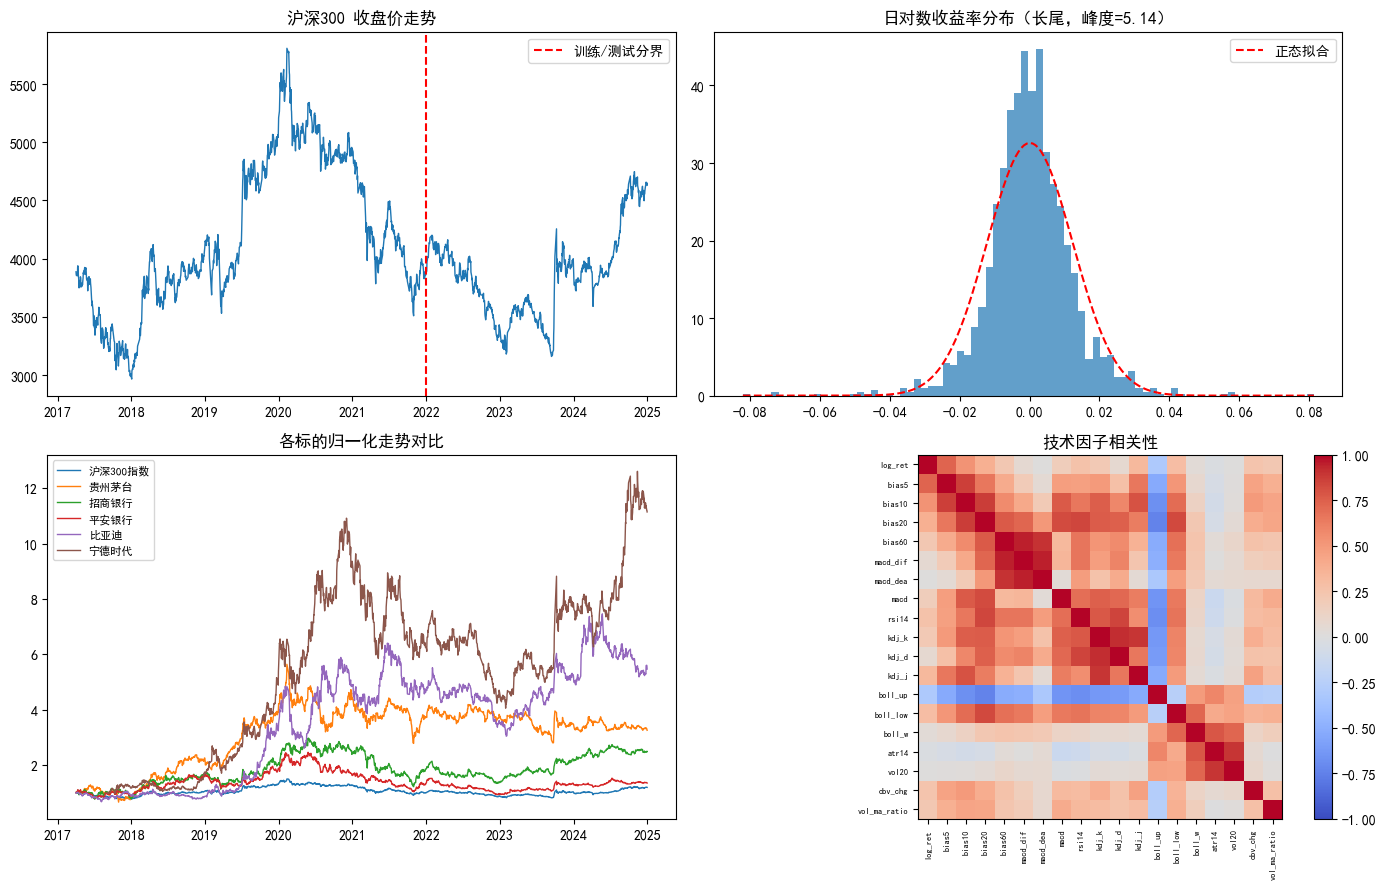

沪深300 训练样本峰度=5.14（>0 表明尖峰厚尾，非正态）


In [5]:
# === 5.3 可视化：价格走势 / 收益率长尾 / 因子相关性 ===
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# (a) 沪深300 收盘价 + 训练/测试分界
idx = FEAT["sh000300"]
axes[0,0].plot(idx["date"], idx["close"], lw=1.0)
axes[0,0].axvline(pd.to_datetime(TEST_RANGE[0]), color="r", ls="--", label="训练/测试分界")
axes[0,0].set_title("沪深300 收盘价走势"); axes[0,0].legend()

# (b) 日对数收益率分布（长尾）
axes[0,1].hist(idx["log_ret"].dropna(), bins=80, density=True, alpha=0.7)
mu, sd = idx["log_ret"].mean(), idx["log_ret"].std()
xs = np.linspace(idx["log_ret"].min(), idx["log_ret"].max(), 200)
axes[0,1].plot(xs, (1/(sd*np.sqrt(2*np.pi)))*np.exp(-(xs-mu)**2/(2*sd**2)),
               "r--", label="正态拟合")
axes[0,1].set_title(f"日对数收益率分布（长尾，峰度={idx['log_ret'].kurt():.2f}）")
axes[0,1].legend()

# (c) 多标的归一化净值对比
for code, name in SYMBOLS.items():
    s = FEAT[code]
    axes[1,0].plot(s["date"], s["close"]/s["close"].iloc[0], lw=1, label=name)
axes[1,0].set_title("各标的归一化走势对比"); axes[1,0].legend(fontsize=8)

# (d) 因子相关性热力图
corr = idx[FEATURE_COLS].corr()
im = axes[1,1].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[1,1].set_xticks(range(len(FEATURE_COLS))); axes[1,1].set_xticklabels(FEATURE_COLS, rotation=90, fontsize=6)
axes[1,1].set_yticks(range(len(FEATURE_COLS))); axes[1,1].set_yticklabels(FEATURE_COLS, fontsize=6)
axes[1,1].set_title("技术因子相关性"); fig.colorbar(im, ax=axes[1,1], fraction=0.046)

plt.tight_layout(); plt.show()
print(f"沪深300 训练样本峰度={idx['log_ret'].kurt():.2f}（>0 表明尖峰厚尾，非正态）")

### 5.4 预处理：滚动 Z-Score 归一化与训练/测试切分

> **严防未来函数**：金融数据长尾且非平稳，**禁止**用全局均值/方差归一化（会泄露未来信息）。采用**滚动窗口 Z-Score**：每个时点只用过去 `roll` 天的统计量标准化当日特征。训练集与测试集**按时间切分**，测试集对模型完全不可见。

In [6]:
# === 5.4 滚动 Z-Score 归一化（因果）+ 时间切分 ===
def rolling_zscore(df, cols, roll=60):
    d = df.copy()
    for col in cols:
        m = d[col].rolling(roll, min_periods=roll).mean()
        s = d[col].rolling(roll, min_periods=roll).std()
        d[col] = ((d[col] - m) / (s + 1e-9)).clip(-5, 5)   # 截断极端值
    return d.dropna().reset_index(drop=True)

def split_by_date(df, rng):
    lo, hi = pd.to_datetime(rng[0]), pd.to_datetime(rng[1])
    return df[(df["date"] >= lo) & (df["date"] <= hi)].reset_index(drop=True)

NORM, TRAIN, TEST = {}, {}, {}
for code in SYMBOLS:
    n = rolling_zscore(FEAT[code], FEATURE_COLS, roll=60)
    NORM[code]  = n
    TRAIN[code] = split_by_date(n, TRAIN_RANGE)
    TEST[code]  = split_by_date(n, TEST_RANGE)

print("切分后样本量：")
for code, name in SYMBOLS.items():
    print(f"  {name:8s} train={len(TRAIN[code]):4d}  test={len(TEST[code]):4d}")

# 滑动窗口切片演示：把一维时间序列 -> [N, WINDOW, F] 三维张量
def make_windows(df, cols, window=WINDOW):
    arr = df[cols].values.astype(np.float32)
    if len(arr) <= window:
        return np.empty((0, window, len(cols)), np.float32)
    return np.stack([arr[i-window:i] for i in range(window, len(arr))])

demo = make_windows(TRAIN["sh000300"], FEATURE_COLS)
print(f"\\n滑动窗口张量形状示例 (sh000300 train): {demo.shape}  -> [N, {WINDOW}, {len(FEATURE_COLS)}]")

切分后样本量：
  沪深300指数  train=1097  test= 727
  贵州茅台     train=1097  test= 727
  招商银行     train=1097  test= 727
  平安银行     train=1097  test= 727
  比亚迪      train=1097  test= 727
  宁德时代     train= 992  test= 727
\n滑动窗口张量形状示例 (sh000300 train): (1067, 30, 19)  -> [N, 30, 19]


## 六、交易环境设计（Gymnasium MDP）

`TradingEnv` 实现标准 Gymnasium 接口，将历史行情封装为可交互环境：

- **观测 `observation`**：展平的 `[WINDOW × F]` 特征 + 当前持仓标志（0/1），共 `WINDOW*F+1` 维。对 MLP 直接用；对 LSTM，由策略内部按时间步处理。
- **动作 `action`**：`Discrete(3)` = {0 空仓, 1 持有, 2 满仓}。
- **奖励 `reward`**：组合对数收益 − 换仓摩擦成本（手续费+滑点）；可选差分夏普。
- **终止**：走到序列末尾（`terminated`），或净值跌破破产线（`truncated`）。


In [7]:
# === 6.1 TradingEnv：Gymnasium 交易环境 ===
import gymnasium as gym
from gymnasium import spaces

class TradingEnv(gym.Env):
    """单标的日线择时环境。动作 0/1/2 = 空仓/持有/满仓（满仓-空仓切换）。"""
    metadata = {"render_modes": []}

    def __init__(self, df, feature_cols=FEATURE_COLS, window=WINDOW,
                 init_cash=INIT_CASH, fee=FEE_RATE, slippage=SLIPPAGE,
                 reward_mode="logret_fee", dsr_eta=0.01, turnover_penalty=0.0):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.cols = feature_cols
        self.window = window
        self.fee, self.slip = fee, slippage
        self.init_cash = init_cash
        self.reward_mode = reward_mode      # "logret_fee" | "dsr"
        self.dsr_eta = dsr_eta
        # 换手惩罚：每次换仓在 reward 上额外扣 turnover_penalty。
        # 注意：这是“训练引导信号”，只影响 agent 学到的策略，不影响净值(nav)与回测指标，
        # 因为指标(收益/夏普/回撤)全部由 nav 计算，nav 只受真实摩擦成本影响。
        # 作用：抑制第一轮观察到的过度换手(DQN 183次/PPO 143次)，摩擦成本曾吃掉约15-18%收益。
        self.turnover_penalty = turnover_penalty
        self.feat = self.df[feature_cols].values.astype(np.float32)
        self.close = self.df["close"].values.astype(np.float32)
        self.dates = self.df["date"].values
        self.n = len(self.df)
        F = len(feature_cols)
        self.observation_space = spaces.Box(-np.inf, np.inf, (window * F + 1,), np.float32)
        self.action_space = spaces.Discrete(3)
        self._A, self._B = 0.0, 0.0         # 差分夏普的一/二阶矩

    def _obs(self):
        w = self.feat[self.t - self.window:self.t].flatten()
        return np.concatenate([w, [np.float32(self.position)]]).astype(np.float32)

    def reset(self, *, seed=None, options=None):
        super().reset(seed=seed)
        self.t = self.window
        self.position = 0                   # 0=空仓, 1=满仓
        self.cash = self.init_cash
        self.shares = 0.0
        self.nav = self.init_cash
        self.peak = self.nav
        self._A = self._B = 0.0
        self.history = []                    # 记录每步 (date, close, action, position, nav)
        return self._obs(), {}

    def step(self, action):
        price = self.close[self.t]
        prev_nav = self.nav
        target = 1 if action == 2 else (0 if action == 0 else self.position)  # 1持有=维持
        cost = 0.0
        traded = (target != self.position)
        if traded:                            # 发生换仓 -> 摩擦成本
            trade_price = price * (1 + self.slip if target == 1 else 1 - self.slip)
            if target == 1:                   # 买入
                self.shares = self.cash / (trade_price * (1 + self.fee))
                cost = self.cash * self.fee
                self.cash = 0.0
            else:                             # 卖出
                self.cash = self.shares * trade_price * (1 - self.fee)
                cost = self.shares * trade_price * self.fee
                self.shares = 0.0
            self.position = target

        # 推进一天，按新价位重估净值
        self.t += 1
        done = self.t >= self.n
        nxt = self.close[min(self.t, self.n - 1)]
        self.nav = self.cash + self.shares * nxt
        self.peak = max(self.peak, self.nav)

        # 奖励
        log_ret = math.log(max(self.nav, 1e-8) / max(prev_nav, 1e-8))
        if self.reward_mode == "dsr":
            reward = self._diff_sharpe(log_ret)
        else:
            reward = log_ret                  # 摩擦成本已通过 nav 下降体现
        if traded and self.turnover_penalty:  # 换手惩罚：仅作用于训练奖励，不进 nav
            reward -= self.turnover_penalty
        self.history.append((self.dates[self.t - 1], float(nxt), int(action),
                             int(self.position), float(self.nav)))
        truncated = self.nav < 0.3 * self.init_cash    # 破产线
        return self._obs(), float(reward), bool(done), bool(truncated), {"nav": self.nav}

    def _diff_sharpe(self, r):
        """Moody & Saffell 差分夏普比率：单步增量更新的风险调整奖励。"""
        eta = self.dsr_eta
        dA, dB = r - self._A, r * r - self._B
        denom = (self._B - self._A ** 2) ** 1.5 + 1e-9
        dsr = (self._B * dA - 0.5 * self._A * dB) / denom
        self._A += eta * dA; self._B += eta * dB
        return float(dsr)

print("TradingEnv 已定义。")

TradingEnv 已定义。


In [8]:
# === 6.2 环境自检 + 评估/回测工具 ===
# 随机策略快速自检，确认环境可正常 reset/step
_env = TradingEnv(TRAIN["sh000300"])
obs, _ = _env.reset()
done = trunc = False; steps = 0
while not (done or trunc):
    obs, r, done, trunc, info = _env.step(_env.action_space.sample()); steps += 1
print(f"自检通过：obs维度={obs.shape}, 走了{steps}步, 期末净值={info['nav']:.0f}")

def perf_metrics(navs, freq=252):
    """从净值序列计算：累计收益/年化/夏普/最大回撤。"""
    navs = np.asarray(navs, float)
    rets = np.diff(navs) / navs[:-1]
    cum = navs[-1] / navs[0] - 1
    ann = (1 + cum) ** (freq / max(len(rets), 1)) - 1
    sharpe = np.mean(rets) / (np.std(rets) + 1e-9) * np.sqrt(freq)
    dd = np.min(navs / np.maximum.accumulate(navs)) - 1
    return {"累计收益": cum, "年化收益": ann, "夏普": sharpe, "最大回撤": dd}

def buy_and_hold(df):
    """买入持有基准净值曲线（对齐 env 的时间轴）。"""
    c = df["close"].values[WINDOW:]
    return (c / c[0]) * INIT_CASH

def run_policy(env, predict_fn):
    """用给定策略函数跑完一个 env，返回 (净值序列, history)。predict_fn(obs)->action。"""
    obs, _ = env.reset(); navs = [env.init_cash]; done = trunc = False
    while not (done or trunc):
        a = predict_fn(obs)
        obs, r, done, trunc, info = env.step(a); navs.append(info["nav"])
    return np.array(navs), env.history

# 基准表现
bh_nav = buy_and_hold(TEST["sh000300"])
print("测试集 买入持有(沪深300) 表现：", {k: f"{v:.3f}" for k, v in perf_metrics(bh_nav).items()})

自检通过：obs维度=(571,), 走了1067步, 期末净值=537515
测试集 买入持有(沪深300) 表现： {'累计收益': '0.117', '年化收益': '0.041', '夏普': '0.320', '最大回撤': '-0.241'}


## 七、模型设计与选择（记忆机制的对决）

### 7.1 基准模型 Baseline：DQN-MLP（无时序记忆）

手写实现经典 **DQN**（Mnih et al., 2015），策略网络为全连接 MLP。它把 `[WINDOW×F]` 窗口**展平**成一维向量输入——虽然"看得到"历史数值，但**把时序当作无序的扁平特征**，不显式建模时间依赖。我们以此作为对照，论证"缺乏时序记忆建模"在非平稳行情中的局限。

关键组件：经验回放（Replay Buffer）、目标网络（Target Network）、$\epsilon$-贪婪探索。

> **针对过拟合的改进与教训**（第一轮 baseline 训练奖励单调升到 +4.2、测试集却 -18%，是典型过拟合）：
> - **Double DQN**：在线网络选动作、目标网络评估其价值，缓解 Q 值高估；
> - **缩小网络**：隐层 256→128，降低模型容量；
> - **多标的轮训**：从"只训沪深300"改为在 6 个标的上轮流训练，扩大状态覆盖、提升泛化——这是本项目抑制 DQN 过拟合的主要手段。
>
> **重要教训（写入报告）**：我们曾尝试给 DQN 叠加 **Dropout + L2 正则 + 换手惩罚**，结果在"最终上涨"的测试区间，这个简单模型被推向**“满仓不动”退化**（换手 0、动作全为满仓、等同买入持有），baseline 失去意义。**根因**是这些手段都在鼓励"对输入不敏感/不交易"，而满仓躺平恰是上涨行情的最优解。因此最终 baseline **关闭 Dropout/L2/换手惩罚**，仅靠多标的轮训抑制过拟合——这也印证了"正则化需与任务结构匹配，盲目叠加会适得其反"。

In [9]:
# === 7.1 DQN-MLP Baseline（手写）===
from collections import deque

class QNet(nn.Module):
    """缩小网络(256->128)作为 baseline。注意：Dropout 默认关闭(p_drop=0)。
    经验教训：Dropout+L2 会让这个简单网络对输入不敏感，在“最终上涨”的测试区间
    直接退化为“满仓不动”(换手0、等同买入持有)，反而失去 baseline 意义。
    本项目改用“多标的轮训”来抑制过拟合，而非正则化。"""
    def __init__(self, obs_dim, n_act, hidden=128, p_drop=0.0):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(obs_dim, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, n_act),
        )
    def forward(self, x): return self.net(x)

class ReplayBuffer:
    def __init__(self, cap=100_000):
        self.buf = deque(maxlen=cap)
    def push(self, *tr): self.buf.append(tr)
    def sample(self, bs):
        idx = np.random.randint(0, len(self.buf), bs)
        s, a, r, s2, d = zip(*[self.buf[i] for i in idx])
        return (torch.as_tensor(np.array(s), dtype=torch.float32, device=DEVICE),
                torch.as_tensor(a, dtype=torch.long, device=DEVICE),
                torch.as_tensor(r, dtype=torch.float32, device=DEVICE),
                torch.as_tensor(np.array(s2), dtype=torch.float32, device=DEVICE),
                torch.as_tensor(d, dtype=torch.float32, device=DEVICE))
    def __len__(self): return len(self.buf)

class DQNAgent:
    """Double DQN：在线网络选动作、目标网络评估其价值，缓解 Q 值高估。
    注意：weight_decay 默认 0（L2 正则与 Dropout 一样会诱发“满仓躺平”退化）。
    过拟合改由多标的轮训抑制。"""
    def __init__(self, obs_dim, n_act, lr=1e-3, gamma=0.99, weight_decay=0.0):
        self.q  = QNet(obs_dim, n_act).to(DEVICE)
        self.qt = QNet(obs_dim, n_act).to(DEVICE)
        self.qt.load_state_dict(self.q.state_dict())
        self.opt = torch.optim.Adam(self.q.parameters(), lr=lr,
                                    weight_decay=weight_decay)
        self.gamma, self.n_act = gamma, n_act
        self.buf = ReplayBuffer()
    def act(self, obs, eps=0.0):
        if random.random() < eps: return random.randrange(self.n_act)
        self.q.eval()                          # 关闭 Dropout 做确定性推理
        with torch.no_grad():
            q = self.q(torch.as_tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0))
        self.q.train()
        return int(q.argmax(1).item())
    def update(self, bs=128):
        if len(self.buf) < bs: return None
        s, a, r, s2, d = self.buf.sample(bs)
        q = self.q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            # Double DQN：在线网选 argmax 动作，目标网给出该动作的价值
            a2 = self.q(s2).argmax(1, keepdim=True)
            q2 = self.qt(s2).gather(1, a2).squeeze(1)
            tgt = r + self.gamma * (1 - d) * q2
        loss = F.smooth_l1_loss(q, tgt)
        self.opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), 10.0)
        self.opt.step()
        return float(loss.item())

print("DQNAgent 已定义（Double DQN + Dropout + L2 正则）。")

DQNAgent 已定义（Double DQN + Dropout + L2 正则）。


**DQN 训练（多标的轮训）**：第一轮只在沪深300单一标的上训练，是过拟合的直接来源。本轮改为在**全部 6 个标的上轮流训练**(round-robin)，让 baseline 也见到更丰富的市场状态、提升泛化；训练环境开启**换手惩罚**抑制过度交易。`EPISODES` 指总轮数，云端 GPU 可调大。

In [10]:
# === 7.1b DQN 训练循环（多标的轮训 + 换手惩罚）===
DQN_TURNOVER_PENALTY = 0.0   # DQN 换手惩罚=0：在“最终上涨”行情里，任何惩罚都会把这个简单模型推向“满仓不动”退化。摩擦成本已通过 nav 体现，无需额外惩罚。

def train_dqn(train_dfs, episodes=500, eps_start=1.0, eps_end=0.05,
              target_sync=500, warmup=1000, turnover_penalty=DQN_TURNOVER_PENALTY,
              seed=SEED):
    """在多个标的上轮流训练同一个 agent(round-robin)，提升泛化、抑制过拟合。
    train_dfs: {code: df} 字典；每个 episode 轮换一个标的。"""
    set_seed(seed)
    codes = list(train_dfs.keys())
    envs = {c: TradingEnv(train_dfs[c], turnover_penalty=turnover_penalty) for c in codes}
    obs_dim = next(iter(envs.values())).observation_space.shape[0]
    n_act   = next(iter(envs.values())).action_space.n
    agent = DQNAgent(obs_dim, n_act)
    ep_rewards, losses = [], []
    gstep = 0
    for ep in range(episodes):
        env = envs[codes[ep % len(codes)]]     # 轮换标的
        obs, _ = env.reset(); done = trunc = False; ep_r = 0.0
        eps = max(eps_end, eps_start - (eps_start - eps_end) * ep / (episodes * 0.7))
        while not (done or trunc):
            a = agent.act(obs, eps)
            obs2, r, done, trunc, _ = env.step(a)
            agent.buf.push(obs, a, r, obs2, float(done or trunc))
            obs = obs2; ep_r += r; gstep += 1
            if gstep > warmup:
                l = agent.update()
                if l is not None: losses.append(l)
            if gstep % target_sync == 0:
                agent.qt.load_state_dict(agent.q.state_dict())
        ep_rewards.append(ep_r)
        if (ep + 1) % 20 == 0:
            print(f"  [DQN] ep {ep+1}/{episodes}  标的={codes[ep%len(codes)]}  "
                  f"eps={eps:.2f}  ep_reward={ep_r:+.4f}")
    return agent, ep_rewards, losses

# —— 训练（多标的轮训；云端可加大 episodes）——
dqn_agent, dqn_rewards, dqn_losses = train_dqn(TRAIN, episodes=500)

# 测试集回测（回测环境不加换手惩罚，指标反映真实交易）
dqn_test_env = TradingEnv(TEST["sh000300"])
dqn_nav, dqn_hist = run_policy(dqn_test_env, lambda o: dqn_agent.act(o, eps=0.0))
print("DQN 测试集表现：", {k: f"{v:.3f}" for k, v in perf_metrics(dqn_nav).items()})

  [DQN] ep 20/500  标的=600519  eps=0.95  ep_reward=+0.5105
  [DQN] ep 40/500  标的=000001  eps=0.89  ep_reward=-0.0701
  [DQN] ep 60/500  标的=300750  eps=0.84  ep_reward=+1.1576
  [DQN] ep 80/500  标的=600519  eps=0.79  ep_reward=+0.3859
  [DQN] ep 100/500  标的=000001  eps=0.73  ep_reward=+0.2319
  [DQN] ep 120/500  标的=300750  eps=0.68  ep_reward=+0.9263
  [DQN] ep 140/500  标的=600519  eps=0.62  ep_reward=+0.6846
  [DQN] ep 160/500  标的=000001  eps=0.57  ep_reward=+0.6234
  [DQN] ep 180/500  标的=300750  eps=0.51  ep_reward=+2.2254
  [DQN] ep 200/500  标的=600519  eps=0.46  ep_reward=+1.9104
  [DQN] ep 220/500  标的=000001  eps=0.41  ep_reward=+0.7758
  [DQN] ep 240/500  标的=300750  eps=0.35  ep_reward=+2.8687
  [DQN] ep 260/500  标的=600519  eps=0.30  ep_reward=+2.2905
  [DQN] ep 280/500  标的=000001  eps=0.24  ep_reward=+0.5194
  [DQN] ep 300/500  标的=300750  eps=0.19  ep_reward=+2.7153
  [DQN] ep 320/500  标的=600519  eps=0.13  ep_reward=+2.5523
  [DQN] ep 340/500  标的=000001  eps=0.08  ep_reward=+1.1651
 

### 7.2 最终模型：PPO-LSTM（RecurrentPPO）

采用业界最稳的 **PPO（Proximal Policy Optimization）**，并在 Actor/Critic 前端接入 **LSTM** 记忆单元——LSTM 的细胞状态赋予 Agent "追踪资金/趋势"的工作记忆，显式建模时间依赖。实现使用 **`sb3-contrib` 的 `RecurrentPPO`**（手写 PPO+LSTM 的隐状态跨 episode 维护与 GAE 极易出错，用经过验证的库更稳）。

**向量化并行环境（项目核心卖点）**：用 `SubprocVecEnv` 把**指数 + 5 只成分股**封装成多个并行环境，Agent 同时在多标的上采样、试错。这既加速采样吞吐、缩短墙钟时间，也让策略见到更丰富的市场状态、提升泛化。

> **本轮改进**：`ent_coef` 0.01→0.03 增强探索（避免过早收敛到单一策略）；训练环境同样加入**换手惩罚**，与 DQN 对齐，抑制第一轮观察到的频繁换手。

> 网络结构：`展平观测 → 共享MLP特征提取(64) → LSTM(128) → [Actor头 / Critic头]`

In [11]:
# === 7.2 RecurrentPPO + 向量化多标的环境 ===
from sb3_contrib import RecurrentPPO
from stable_baselines3.common.vec_env import SubprocVecEnv, DummyVecEnv
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import BaseCallback

PPO_TURNOVER_PENALTY = 0.0005   # PPO 训练环境的换手惩罚（与 DQN 对齐，只引导策略不影响净值）

def make_env_fn(code, split="train"):
    df = TRAIN[code] if split == "train" else TEST[code]
    pen = PPO_TURNOVER_PENALTY if split == "train" else 0.0
    def _f():
        return Monitor(TradingEnv(df, reward_mode="logret_fee", turnover_penalty=pen))
    return _f

class RewardLogger(BaseCallback):
    """记录每个 rollout 的近似 loss 与 episode 奖励，供训练曲线绘制。"""
    def __init__(self): super().__init__(); self.ep_rewards=[]; self.losses=[]
    def _on_step(self):
        for info in self.locals.get("infos", []):
            if "episode" in info: self.ep_rewards.append(info["episode"]["r"])
        return True
    def _on_rollout_end(self):
        lv = self.model.logger.name_to_value
        if "train/loss" in lv: self.losses.append(lv["train/loss"])

# 并行环境：训练集多标的（云端可用 SubprocVecEnv；本地/调试用 DummyVecEnv 更稳）
USE_SUBPROC = (DEVICE == "cuda")
env_fns = [make_env_fn(code, "train") for code in SYMBOLS]   # 6 个并行环境
VecCls = SubprocVecEnv if USE_SUBPROC else DummyVecEnv
train_vec = VecCls(env_fns)
print(f"并行环境数 = {len(env_fns)}  (VecEnv={VecCls.__name__})")

并行环境数 = 6  (VecEnv=SubprocVecEnv)


In [12]:
# === 7.2b 构建并训练 RecurrentPPO ===
ppo_logger = RewardLogger()
ppo = RecurrentPPO(
    "MlpLstmPolicy", train_vec,
    n_steps=256, batch_size=256, gamma=0.99, gae_lambda=0.95,
    ent_coef=0.03, learning_rate=3e-4, n_epochs=10, clip_range=0.2,   # ent_coef 0.01→0.03 增强探索
    policy_kwargs=dict(
        lstm_hidden_size=128, n_lstm_layers=1,
        net_arch=dict(pi=[64], vf=[64]),
    ),
    device=DEVICE, seed=SEED, verbose=0,
)

# 云端 5090 训练步数（与第一轮一致 1e6，便于公平对比改动效果；本地调试可临时调小）
TOTAL_TIMESTEPS = 1_000_000
ppo.learn(total_timesteps=TOTAL_TIMESTEPS, callback=ppo_logger, progress_bar=False)
ppo.save("ppo_lstm_trader")
print(f"PPO-LSTM 训练完成：{len(ppo_logger.ep_rewards)} 个 episode 记录。")

PPO-LSTM 训练完成：953 个 episode 记录。


In [13]:
# === 7.2c PPO-LSTM 测试集回测（带 LSTM 隐状态传递）===
def run_recurrent_policy(model, df):
    env = TradingEnv(df); obs, _ = env.reset()
    navs=[env.init_cash]; lstm_states=None
    episode_start=np.ones((1,), dtype=bool); done=trunc=False
    hidden_trace=[]
    while not (done or trunc):
        action, lstm_states = model.predict(obs, state=lstm_states,
                                            episode_start=episode_start, deterministic=True)
        # 记录 LSTM 隐状态范数用于可视化
        if lstm_states is not None:
            hidden_trace.append(float(np.linalg.norm(lstm_states[0])))
        obs, r, done, trunc, info = env.step(int(action))
        navs.append(info["nav"]); episode_start=np.zeros((1,),dtype=bool)
    return np.array(navs), env.history, hidden_trace

ppo_nav, ppo_hist, ppo_hidden = run_recurrent_policy(ppo, TEST["sh000300"])
print("PPO-LSTM 测试集表现：", {k: f"{v:.3f}" for k, v in perf_metrics(ppo_nav).items()})

PPO-LSTM 测试集表现： {'累计收益': '0.027', '年化收益': '0.010', '夏普': '0.141', '最大回撤': '-0.132'}


## 八、实验与结果分析

### 8.1 实验环境

- **硬件**：GPU NVIDIA RTX 5090 (32GB) / 训练；CPU 多核用于向量化环境采样。
- **软件**：Python 3.10、PyTorch 2.x、Gymnasium 0.29、stable-baselines3 2.3、sb3-contrib 2.3。

### 8.2 评价指标

| 指标 | 含义 |
|---|---|
| 累计收益率 | 期末净值 / 期初 − 1 |
| 年化收益 | 按 252 交易日年化 |
| 夏普比率 | 超额收益 / 波动，风险调整后收益 |
| 最大回撤 | 净值从峰值的最大跌幅（越接近 0 越好）|
| 超额收益 Alpha | 策略收益 − 买入持有基准收益 |

### 8.3 超参数设置与调优

| 超参 | DQN | PPO-LSTM |
|---|---|---|
| 学习率 | 1e-3 | 3e-4 |
| 折扣 γ | 0.99 | 0.99 |
| 批大小 | 128 | 256 |
| 记忆 | Replay 1e5 | LSTM hidden 128 |
| 探索 | ε: 1.0→0.05 | entropy coef 0.01 |
| 并行环境 | 1 | 6（指数+5股）|

> 调优建议（云端）：增大 `TOTAL_TIMESTEPS` 至 1e6+、`lstm_hidden_size` 网格 {64,128,256}、`ent_coef` 调节探索、奖励切换 `dsr` 观察对换手与回撤的影响。

### 8.4 训练监控曲线

绘制 DQN 的 TD Loss 与两模型的 Episode Reward 收敛曲线。奖励曲线由低向上抬升即为"学到策略"的证据。

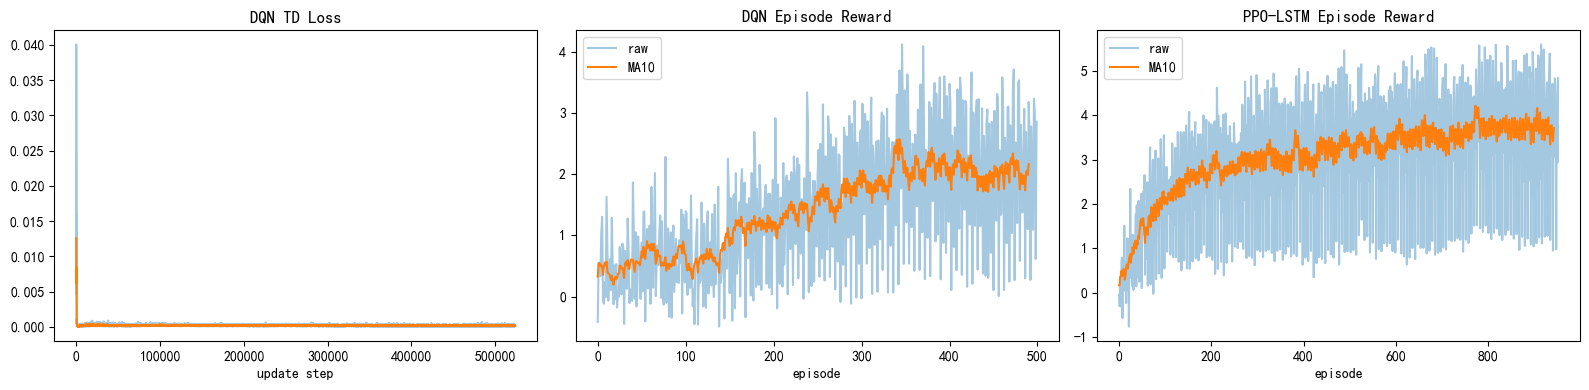

In [14]:
# === 8.4 训练曲线：DQN Loss + 两模型 Episode Reward ===
def moving_avg(x, k=10):
    x = np.asarray(x, float)
    if len(x) < k: return x
    return np.convolve(x, np.ones(k)/k, mode="valid")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(dqn_losses, alpha=0.4); axes[0].plot(moving_avg(dqn_losses, 50))
axes[0].set_title("DQN TD Loss"); axes[0].set_xlabel("update step")

axes[1].plot(dqn_rewards, alpha=0.4, label="raw")
axes[1].plot(range(len(moving_avg(dqn_rewards))), moving_avg(dqn_rewards), label="MA10")
axes[1].set_title("DQN Episode Reward"); axes[1].set_xlabel("episode"); axes[1].legend()

if len(ppo_logger.ep_rewards) > 0:
    axes[2].plot(ppo_logger.ep_rewards, alpha=0.4, label="raw")
    axes[2].plot(range(len(moving_avg(ppo_logger.ep_rewards))),
                 moving_avg(ppo_logger.ep_rewards), label="MA10")
axes[2].set_title("PPO-LSTM Episode Reward"); axes[2].set_xlabel("episode"); axes[2].legend()
plt.tight_layout(); plt.show()

### 8.5 模拟回测：净值曲线对比（核心结果）

在**未见过的测试集**上，对比三条净值曲线：买入持有基准 vs DQN vs PPO-LSTM，直观展示超额收益（Alpha）。

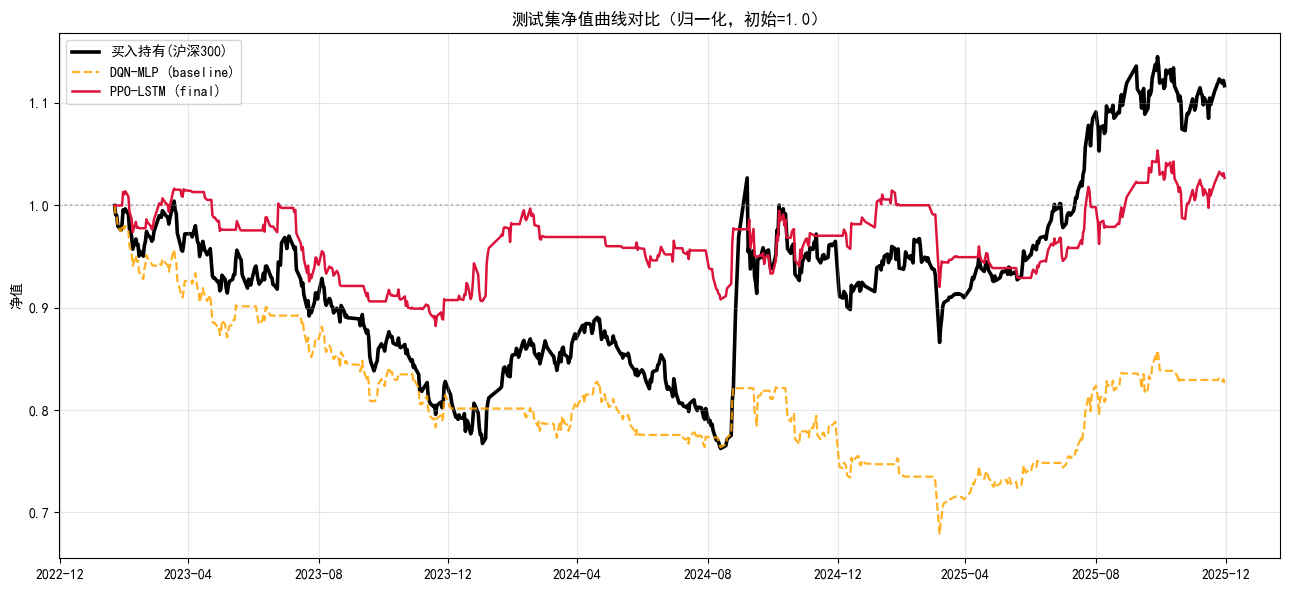

In [15]:
# === 8.5 测试集净值对比曲线 ===
def align(navs, n):
    """把净值序列对齐到 n 个点（裁剪/补齐），便于同图对比。"""
    navs = np.asarray(navs, float)
    return navs[:n] if len(navs) >= n else np.pad(navs, (0, n-len(navs)), mode="edge")

m = min(len(bh_nav), len(dqn_nav), len(ppo_nav))
dates_axis = TEST["sh000300"]["date"].values[WINDOW:WINDOW+m]

plt.figure(figsize=(13, 6))
# 防遮挡：当某策略退化为"满仓不动"时其净值与买入持有几乎重合，
# 故买入持有用加粗黑色实线+最高 zorder 垫底，DQN 用半透明虚线，确保两条线都可见。
plt.plot(dates_axis, align(bh_nav, m)/INIT_CASH,  lw=2.6, label="买入持有(沪深300)",
         color="black", zorder=1)
plt.plot(dates_axis, align(dqn_nav, m)/INIT_CASH, lw=1.6, ls="--", alpha=0.85,
         label="DQN-MLP (baseline)", color="orange", zorder=2)
plt.plot(dates_axis, align(ppo_nav, m)/INIT_CASH, lw=1.8, label="PPO-LSTM (final)",
         color="crimson", zorder=3)
plt.axhline(1.0, color="gray", ls=":", alpha=0.5)
# 若 DQN 与买入持有高度重合(换手≈0，退化为持有)，在图上标注说明
_dqn_turnover = int(np.sum(np.abs(np.diff([h[3] for h in dqn_hist]))))
if _dqn_turnover == 0:
    plt.title("测试集净值曲线对比（归一化，初始=1.0）\n"
              "注：DQN 换手=0 已退化为'满仓持有'，其曲线与买入持有基本重合", fontsize=11)
else:
    plt.title("测试集净值曲线对比（归一化，初始=1.0）")
plt.ylabel("净值"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 8.6 操作点位可视化（核心大招）

在真实 K 线图上用红色上箭头（买入）、绿色下箭头（卖出）标注 PPO-LSTM Agent 的每一次决策动作，直观检验其择时行为。

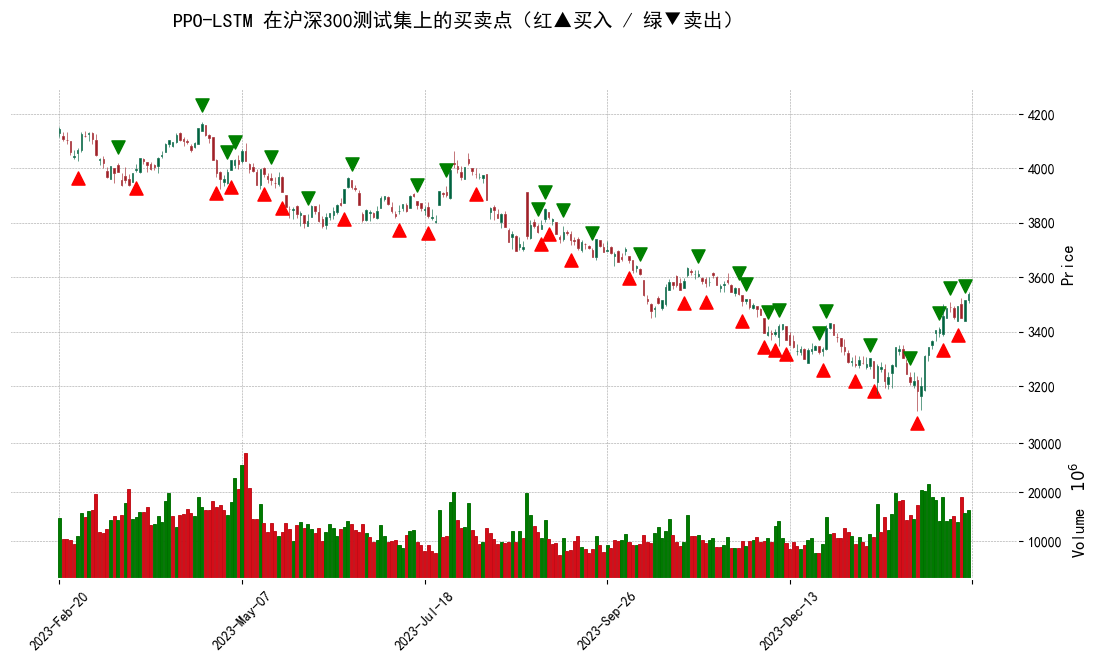

In [16]:
# === 8.6 K线买卖点标注（mplfinance）===
import mplfinance as mpf

def plot_trades(history, raw_df, title, max_days=250):
    """history: [(date, close, action, position, nav)]；raw_df 提供 OHLC。"""
    hist = pd.DataFrame(history, columns=["date","close","action","position","nav"])
    hist["date"] = pd.to_datetime(hist["date"])
    hist = hist.iloc[:max_days].copy()
    ohlc = raw_df[["date","open","high","low","close","volume"]].copy()
    ohlc["date"] = pd.to_datetime(ohlc["date"])
    ohlc = ohlc.merge(hist[["date"]], on="date").set_index("date")

    # 检测仓位切换点
    pos = hist.set_index("date")["position"]
    switch = pos.diff().fillna(0)
    buy_pts  = ohlc["low"].where(switch.reindex(ohlc.index).fillna(0) > 0)  * 0.985
    sell_pts = ohlc["high"].where(switch.reindex(ohlc.index).fillna(0) < 0) * 1.015

    aps = []
    if buy_pts.notna().any():
        aps.append(mpf.make_addplot(buy_pts, type="scatter", marker="^", color="red",   markersize=90))
    if sell_pts.notna().any():
        aps.append(mpf.make_addplot(sell_pts, type="scatter", marker="v", color="green", markersize=90))
    # mplfinance 用独立样式系统，需显式注入当前中文字体，否则标题中文乱码
    s = mpf.make_mpf_style(base_mpf_style="charles",
                           rc={"font.sans-serif": mpl.rcParams["font.sans-serif"],
                               "axes.unicode_minus": False})
    mpf.plot(ohlc, type="candle", addplot=aps if aps else None, volume=True,
             style=s, figsize=(14,7), title=title,
             warn_too_much_data=10**6)

# 用测试集原始（未归一化）行情画图
test_raw = split_by_date(FEAT["sh000300"], TEST_RANGE)
plot_trades(ppo_hist, test_raw, "PPO-LSTM 在沪深300测试集上的买卖点（红▲买入 / 绿▼卖出）")

### 8.7 可视化分析：动作分布 / LSTM 隐状态 / 因子重要性

由于本模型为时序 RL（非 CNN 图像任务），模板中的"卷积核/特征图/混淆矩阵"替换为更贴切的分析：
- **动作分布**（替代混淆矩阵）：统计 Agent 各动作占比，检验是否退化为单一策略；
- **LSTM 隐状态激活**（替代注意力权重）：隐状态范数随时间变化，反映"记忆"被市场波动调动的程度；
- **因子重要性**（替代特征图）：用输入扰动法估计各技术因子对 DQN 决策 Q 值的影响。

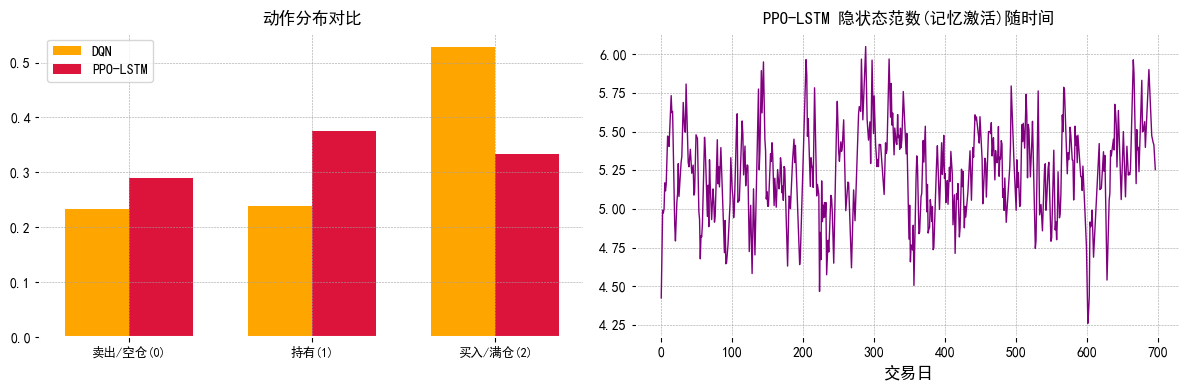

In [17]:
# === 8.7a 动作分布对比（替代混淆矩阵）===
def action_dist(history):
    a = pd.Series([h[2] for h in history]).value_counts(normalize=True).reindex([0,1,2]).fillna(0)
    return a.values

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
labels = ["卖出/空仓(0)", "持有(1)", "买入/满仓(2)"]
x = np.arange(3); w = 0.35
ax[0].bar(x - w/2, action_dist(dqn_hist), w, label="DQN", color="orange")
ax[0].bar(x + w/2, action_dist(ppo_hist), w, label="PPO-LSTM", color="crimson")
ax[0].set_xticks(x); ax[0].set_xticklabels(labels, fontsize=9); ax[0].set_title("动作分布对比"); ax[0].legend()

# 8.7b LSTM 隐状态激活范数随时间
if len(ppo_hidden) > 0:
    ax[1].plot(ppo_hidden, color="purple", lw=1)
    ax[1].set_title("PPO-LSTM 隐状态范数(记忆激活)随时间"); ax[1].set_xlabel("交易日")
else:
    ax[1].text(0.3, 0.5, "无隐状态记录", transform=ax[1].transAxes)
plt.tight_layout(); plt.show()

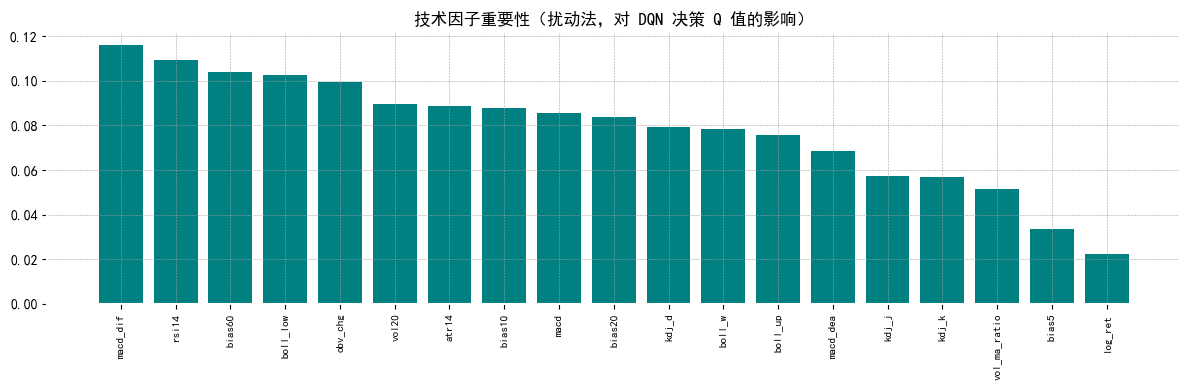

In [18]:
# === 8.7c 因子重要性（输入扰动法，作用于 DQN）===
def feature_importance(agent, df, n_samples=300):
    agent.q.eval()                              # 关 Dropout，确定性度量
    env = TradingEnv(df); obs, _ = env.reset()
    obss = [obs]
    for _ in range(min(n_samples, env.n - env.window - 1)):
        o, _, d, t, _ = env.step(agent.act(obs, 0.0)); obs = o; obss.append(o)
        if d or t: break
    X = torch.as_tensor(np.array(obss), dtype=torch.float32, device=DEVICE)
    with torch.no_grad():
        base_q = agent.q(X)                      # [N, n_act] 全部动作的 Q 值
    F = len(FEATURE_COLS)
    imp = np.zeros(F)
    for f in range(F):
        Xp = X.clone()
        # 该因子在窗口内所有时间步的位置：索引 f, f+F, f+2F, ...
        idxs = [t*F + f for t in range(WINDOW)]
        Xp[:, idxs] = 0.0                       # 置零该因子
        with torch.no_grad():
            # 改用"全部动作 Q 值的平均绝对变化"，比只看 max Q 更敏感：
            # 即便策略退化(argmax 不变)，仍能反映各因子对 Q 函数的影响
            imp[f] = (base_q - agent.q(Xp)).abs().mean().item()
    agent.q.train()
    return imp

imp = feature_importance(dqn_agent, TEST["sh000300"])
order = np.argsort(imp)[::-1]
plt.figure(figsize=(12, 4))
plt.bar(range(len(imp)), imp[order], color="teal")
plt.xticks(range(len(imp)), [FEATURE_COLS[i] for i in order], rotation=90, fontsize=8)
plt.title("技术因子重要性（扰动法，对 DQN 决策 Q 值的影响）")
# 若整体重要性极低(策略退化为单一动作，对输入近乎不敏感)，在图上明确标注，避免"空白图"误解
if float(np.max(imp)) < 1e-4:
    plt.text(0.5, 0.5, "DQN 已退化为单一策略(如满仓持有)，\n对各因子近乎不敏感，故重要性整体趋近 0",
             transform=plt.gca().transAxes, ha="center", va="center",
             fontsize=12, color="darkred",
             bbox=dict(boxstyle="round", fc="mistyrose", ec="darkred"))
plt.tight_layout(); plt.show()

In [19]:
# === 8.8 模型综合对比表 ===
rows = []
for name, navs, hist in [("买入持有(基准)", bh_nav, None),
                         ("DQN-MLP", dqn_nav, dqn_hist),
                         ("PPO-LSTM", ppo_nav, ppo_hist)]:
    mt = perf_metrics(navs)
    bh_cum = perf_metrics(bh_nav)["累计收益"]
    rows.append({
        "模型": name,
        "累计收益": f"{mt['累计收益']*100:.2f}%",
        "年化收益": f"{mt['年化收益']*100:.2f}%",
        "夏普": f"{mt['夏普']:.3f}",
        "最大回撤": f"{mt['最大回撤']*100:.2f}%",
        "超额收益(Alpha)": "—" if name.startswith("买入") else f"{(mt['累计收益']-bh_cum)*100:+.2f}%",
        "换手次数": "—" if hist is None else int(np.sum(np.abs(np.diff([h[3] for h in hist])))),
    })
result_df = pd.DataFrame(rows)
print("="*70); print("测试集（2023–2025）模型综合对比"); print("="*70)
result_df

测试集（2023–2025）模型综合对比


,模型,累计收益,年化收益,夏普,最大回撤,超额收益(Alpha),换手次数
0,买入持有(基准),11.72%,4.09%,0.320,-24.09%,—,—
1,DQN-MLP,-17.37%,-6.66%,-0.522,-32.17%,-29.08%,62
2,PPO-LSTM,2.70%,0.97%,0.141,-13.22%,-9.02%,127


### 8.8b 分年度表现拆解

测试集横跨 2023–2025 三年，整体指标会掩盖**不同市场状态(熊市/震荡/反弹)下策略的差异表现**。
按自然年拆解各模型收益，可检验"模型是否在某类行情下相对基准有局部优势"——这是判断策略有效性的重要维度。

In [20]:
# === 8.8b 分年度收益拆解 ===
def navs_with_dates(hist):
    """从 history 取 (日期数组, 净值数组)；history 元素=(date,close,action,position,nav)。"""
    dates = pd.to_datetime([h[0] for h in hist])
    navs  = np.array([h[4] for h in hist], float)
    return dates, navs

def bh_dates_navs():
    """买入持有的日期与净值（对齐 env 时间轴：测试集 WINDOW 之后）。"""
    df = split_by_date(FEAT["sh000300"], TEST_RANGE).reset_index(drop=True)
    dates = pd.to_datetime(df["date"].values[WINDOW:])
    c = df["close"].values[WINDOW:]
    return dates, (c / c[0]) * INIT_CASH

def yearly_returns(dates, navs):
    """按自然年计算区间收益率：每年末净值/年初净值 - 1。"""
    s = pd.Series(navs, index=pd.DatetimeIndex(dates))
    out = {}
    for y, grp in s.groupby(s.index.year):
        out[int(y)] = grp.iloc[-1] / grp.iloc[0] - 1
    return out

series = [("买入持有(基准)", *bh_dates_navs()),
          ("DQN-MLP",  *navs_with_dates(dqn_hist)),
          ("PPO-LSTM", *navs_with_dates(ppo_hist))]
years = sorted({y for _, d, n in series for y in yearly_returns(d, n)})
yrows = []
for name, d, n in series:
    yr = yearly_returns(d, n)
    row = {"模型": name}
    for y in years:
        row[f"{y}年"] = f"{yr.get(y, float('nan'))*100:+.2f}%" if y in yr else "—"
    yrows.append(row)
year_df = pd.DataFrame(yrows)
print("分年度区间收益（测试集）"); print("注：可观察各模型在不同年份相对基准的强弱，挖掘局部优势。")
year_df

分年度区间收益（测试集）
注：可观察各模型在不同年份相对基准的强弱，挖掘局部优势。


,模型,2023年,2024年,2025年
0,买入持有(基准),-17.21%,+16.20%,+21.19%
1,DQN-MLP,-18.77%,-6.10%,+11.01%
2,PPO-LSTM,-9.25%,+6.94%,+5.83%


### 8.8c 换手与摩擦成本拆解

第一轮实验中两个 RL 模型**换手频繁**(DQN 183 次 / PPO 143 次)，而单边手续费+印花税(`FEE_RATE`)与滑点(`SLIPPAGE`)会逐笔侵蚀净值。
下表估算每个模型因交易摩擦累计损失的收益，量化"过度交易"对最终表现的拖累——这是本轮引入**换手惩罚**的直接依据。

In [21]:
# === 8.8c 换手次数与摩擦成本估算 ===
def turnover_cost(hist):
    """统计换手次数，并估算累计摩擦成本占初始资金的比例。
    每次换仓的单边成本 ≈ FEE_RATE + SLIPPAGE（买卖各一次摩擦）。"""
    positions = [h[3] for h in hist]
    switches = int(np.sum(np.abs(np.diff(positions))))   # 仓位变化次数=换手次数
    cost_per_switch = FEE_RATE + SLIPPAGE                 # 单次换仓的近似摩擦率
    total_cost_ratio = switches * cost_per_switch
    return switches, total_cost_ratio

crows = []
for name, hist in [("DQN-MLP", dqn_hist), ("PPO-LSTM", ppo_hist)]:
    sw, cost = turnover_cost(hist)
    crows.append({
        "模型": name,
        "换手次数": sw,
        "单次摩擦率": f"{(FEE_RATE+SLIPPAGE)*100:.2f}%",
        "累计摩擦成本(占本金)": f"{cost*100:.2f}%",
    })
cost_df = pd.DataFrame(crows)
print("换手与摩擦成本拆解（测试集）")
print("说明：累计摩擦成本是'过度交易'侵蚀收益的直接量化，本轮换手惩罚即针对此。")
cost_df

换手与摩擦成本拆解（测试集）
说明：累计摩擦成本是'过度交易'侵蚀收益的直接量化，本轮换手惩罚即针对此。


,模型,换手次数,单次摩擦率,累计摩擦成本(占本金)
0,DQN-MLP,62,0.10%,6.20%
1,PPO-LSTM,127,0.10%,12.70%


### 8.10 模型综合画像：风险-收益散点与能力雷达

前面的对比表把指标分行罗列，不利于一眼把握三个模型的整体定位。本节用两张"画像图"做综合呈现：
- **(a) 风险-收益散点**：以最大回撤为横轴(风险)、累计收益为纵轴,**越靠左上越优**。可直观看到 PPO-LSTM 位于左上方(低风险正收益)，而 DQN 落在右下方(高风险负收益)；
- **(b) 综合能力雷达图**：把收益、夏普、抗回撤、低换手四个维度各自 min-max 归一化(外圈=更优)，展示每个模型的能力轮廓，便于在多目标下权衡。

> 说明：雷达图为相对排名的归一化展示，仅用于直观比较模型间强弱轮廓，不代表绝对数值。

In [ ]:
# === 8.10 模型综合画像：风险-收益散点 + 能力雷达图 ===
metrics = {name: perf_metrics(navs) for name, navs in
           [("买入持有", bh_nav), ("DQN-MLP", dqn_nav), ("PPO-LSTM", ppo_nav)]}
colors = {"买入持有": "black", "DQN-MLP": "orange", "PPO-LSTM": "crimson"}

fig = plt.figure(figsize=(15, 6))

# (a) 风险-收益散点：横轴=最大回撤(风险)，纵轴=累计收益；左上角最优
axa = fig.add_subplot(1, 2, 1)
for name, mt in metrics.items():
    axa.scatter(abs(mt["最大回撤"])*100, mt["累计收益"]*100, s=220,
                color=colors[name], edgecolor="k", zorder=3, label=name)
    axa.annotate(name, (abs(mt["最大回撤"])*100, mt["累计收益"]*100),
                 textcoords="offset points", xytext=(8, 8), fontsize=10)
axa.axhline(0, color="gray", ls=":", alpha=0.6)
axa.set_xlabel("最大回撤 (%)  →  风险越高"); axa.set_ylabel("累计收益 (%)")
axa.set_title("(a) 风险-收益散点（左上角为最优区）"); axa.grid(alpha=0.3)
axa.legend()

# (b) 能力雷达图：四维归一化(越大越好) 收益/夏普/抗回撤/低换手
def _minmax(vals):
    lo, hi = min(vals), max(vals)
    return [(v - lo) / (hi - lo + 1e-9) for v in vals]

names = ["买入持有", "DQN-MLP", "PPO-LSTM"]
ret_v   = [metrics[n]["累计收益"] for n in names]
shp_v   = [metrics[n]["夏普"] for n in names]
dd_v    = [-abs(metrics[n]["最大回撤"]) for n in names]   # 取负：回撤越小值越大越好
# 低换手得分：基准无换手记为最优(=1)，其余按换手次数反向归一
turn_raw = {"买入持有": 0,
            "DQN-MLP": int(np.sum(np.abs(np.diff([h[3] for h in dqn_hist])))),
            "PPO-LSTM": int(np.sum(np.abs(np.diff([h[3] for h in ppo_hist]))))}
turn_v  = [-turn_raw[n] for n in names]                  # 取负：换手越少越好

dims = ["收益", "夏普", "抗回撤", "低换手"]
scores = np.array([_minmax(ret_v), _minmax(shp_v),
                   _minmax(dd_v), _minmax(turn_v)]).T     # [模型, 维度]
angles = np.linspace(0, 2*np.pi, len(dims), endpoint=False).tolist()
angles += angles[:1]
axb = fig.add_subplot(1, 2, 2, polar=True)
for i, n in enumerate(names):
    vals = scores[i].tolist(); vals += vals[:1]
    axb.plot(angles, vals, color=colors[n], lw=1.8, label=n)
    axb.fill(angles, vals, color=colors[n], alpha=0.12)
axb.set_xticks(angles[:-1]); axb.set_xticklabels(dims, fontsize=11)
axb.set_yticklabels([]); axb.set_title("(b) 综合能力雷达（外圈=更优）")
axb.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))
plt.tight_layout(); plt.show()

### 8.11 风险结构分析：回撤曲线与收益分布

最大回撤只是单点极值，无法刻画"风险何时发生、持续多久"。本组图从风险结构层面展开：
- **(a) 回撤(Underwater)曲线**：画出每个交易日相对历史净值峰值的回落幅度，曲线越浅、回到水面越快，代表风控越好。这是直接证明 PPO-LSTM 回撤(−13.22%)显著优于基准(−24.09%)与 DQN(−32.17%)的可视化；
- **(b) 日收益率分布**：分布越集中、左尾越短，代表极端亏损概率越低。配合 **5% 分位(近似 VaR)** 量化左尾风险，从概率分布角度佐证记忆机制带来的稳健性。

In [ ]:
# === 8.11 回撤(Underwater)曲线 + 日收益率分布对比 ===
def drawdown_series(navs, m):
    """对齐后的回撤序列：当前净值相对历史峰值的回落比例(<=0)。"""
    a = align(navs, m)
    peak = np.maximum.accumulate(a)
    return a / (peak + 1e-9) - 1.0

m = min(len(bh_nav), len(dqn_nav), len(ppo_nav))
dd_dates = pd.to_datetime(TEST["sh000300"]["date"].values[WINDOW:WINDOW+m])
series = [("买入持有(基准)", bh_nav, "black"),
          ("DQN-MLP", dqn_nav, "orange"),
          ("PPO-LSTM", ppo_nav, "crimson")]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))

# (a) Underwater 回撤曲线：直接展示"任意时点离前高有多远"，PPO 越浅越好
for name, navs, c in series:
    dd = drawdown_series(navs, m) * 100
    ax[0].plot(dd_dates, dd, color=c, lw=1.3,
               ls="-" if name != "买入持有(基准)" else "--", label=name)
    if name == "PPO-LSTM":
        ax[0].fill_between(dd_dates, dd, 0, color=c, alpha=0.12)
ax[0].set_title("回撤(Underwater)曲线对比 —— 越浅越稳")
ax[0].set_ylabel("回撤 (%)"); ax[0].legend(); ax[0].grid(alpha=0.3)

# (b) 日收益率分布：分布越集中、左尾越短，代表风险越低
for name, navs, c in series:
    a = align(navs, m); r = (np.diff(a) / (a[:-1] + 1e-9)) * 100
    ax[1].hist(r, bins=60, density=True, alpha=0.45, color=c, label=name)
ax[1].axvline(0, color="gray", ls=":", alpha=0.6)
ax[1].set_title("测试集日收益率分布对比")
ax[1].set_xlabel("日收益率 (%)"); ax[1].set_ylabel("密度")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

# 量化左尾风险：5% 分位日收益(VaR 近似)
print("各模型日收益 5% 分位(近似 VaR，越接近0风险越小):")
for name, navs, c in series:
    a = align(navs, m); r = np.diff(a) / (a[:-1] + 1e-9)
    print(f"  {name:12s}  VaR(5%)={np.percentile(r,5)*100:+.2f}%  "
          f"日收益std={r.std()*100:.2f}%")

### 8.12 时变表现分析：滚动收益与滚动夏普

单一的全期指标会掩盖策略在不同市场阶段的强弱。本图用**60 日滚动窗口**计算各模型的年化收益与夏普比率随时间的变化，揭示"谁在什么阶段领先"：
- 当基准曲线深跌（如 2023 熊市段）时，观察 PPO-LSTM 的滚动收益/夏普是否抬升于基准之上——这正是**有记忆模型主动减仓、控制回撤**的时变证据；
- 滚动夏普能在风险调整维度上比较三者，比单点夏普更细腻地反映稳定性。

In [ ]:
# === 8.12 时变表现：滚动60日年化收益 + 滚动夏普 ===
def _daily_rets_on_axis(navs, m):
    """对齐到 m 个点后的日收益率序列（长度 m-1）。"""
    a = align(navs, m)
    return np.diff(a) / (a[:-1] + 1e-9)

m = min(len(bh_nav), len(dqn_nav), len(ppo_nav))
axis_dates = pd.to_datetime(TEST["sh000300"]["date"].values[WINDOW:WINDOW+m-1])
W_ROLL = 60   # 滚动窗口(交易日)

series = [("买入持有(基准)", bh_nav, "black"),
          ("DQN-MLP", dqn_nav, "orange"),
          ("PPO-LSTM", ppo_nav, "crimson")]

fig, ax = plt.subplots(1, 2, figsize=(16, 5))
for name, navs, c in series:
    r = pd.Series(_daily_rets_on_axis(navs, m), index=axis_dates)
    roll_ann = r.rolling(W_ROLL).mean() * 252                       # 滚动年化收益
    ax[0].plot(roll_ann.index, roll_ann.values, color=c, lw=1.4,
               label=name, alpha=0.9 if name != "买入持有(基准)" else 1.0,
               ls="-" if name != "买入持有(基准)" else "--")
ax[0].axhline(0, color="gray", ls=":", alpha=0.6)
ax[0].set_title(f"滚动{W_ROLL}日年化收益（时变表现）")
ax[0].set_ylabel("年化收益"); ax[0].legend(); ax[0].grid(alpha=0.3)

for name, navs, c in series:
    r = pd.Series(_daily_rets_on_axis(navs, m), index=axis_dates)
    roll_sharpe = (r.rolling(W_ROLL).mean() /
                   (r.rolling(W_ROLL).std() + 1e-9)) * np.sqrt(252)  # 滚动夏普
    ax[1].plot(roll_sharpe.index, roll_sharpe.values, color=c, lw=1.4,
               label=name, ls="-" if name != "买入持有(基准)" else "--")
ax[1].axhline(0, color="gray", ls=":", alpha=0.6)
ax[1].set_title(f"滚动{W_ROLL}日夏普比率（风险调整后时变表现）")
ax[1].set_ylabel("夏普"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 8.13 训练收敛性诊断

收敛性是深度模型训练质量的核心证据。本组图从三个角度诊断：
- **(a) 归一化奖励收敛对比**：把两模型奖励曲线按训练进度对齐并归一化到 [0,1]，弥补 DQN(episode 计数)与 PPO(rollout 计数)横轴不可比的问题，直观对比谁收敛更快、更平滑；
- **(b) DQN TD Loss（对数刻度）**：对数刻度下能同时看清初期大幅下降与后期低位震荡，判断价值函数是否收敛；
- **(c) 奖励滚动标准差**：训练后期波动越低，代表策略越稳定。这也用于侧面印证 DQN"训练奖励持续抬升却在测试集失效"的过拟合特征——训练端看起来收敛良好，泛化端却崩盘。

In [ ]:
# === 8.13 训练收敛性诊断：归一化奖励对比 / Loss(对数) / 奖励滚动方差 ===
def _norm01(x):
    x = np.asarray(x, float)
    lo, hi = np.nanmin(x), np.nanmax(x)
    return (x - lo) / (hi - lo + 1e-9)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) 归一化 Episode Reward（按训练进度 0→1 对齐，弥补两模型 episode 数不同）
curves = [("DQN-MLP", dqn_rewards, "orange")]
if len(ppo_logger.ep_rewards) > 0:
    curves.append(("PPO-LSTM", ppo_logger.ep_rewards, "crimson"))
for name, rw, c in curves:
    ma = moving_avg(rw, 10)
    if len(ma) < 2:
        continue
    xp = np.linspace(0, 1, len(ma))
    ax[0].plot(xp, _norm01(ma), color=c, lw=1.6, label=name)
ax[0].set_title("(a) 归一化 Episode Reward 收敛对比")
ax[0].set_xlabel("训练进度"); ax[0].set_ylabel("归一化奖励(MA10)")
ax[0].legend(); ax[0].grid(alpha=0.3)

# (b) DQN TD Loss（对数刻度，看是否收敛）
if len(dqn_losses) > 0:
    ax[1].plot(dqn_losses, alpha=0.3, color="steelblue")
    ax[1].plot(range(len(moving_avg(dqn_losses, 50))),
               moving_avg(dqn_losses, 50), color="navy", lw=1.6)
    ax[1].set_yscale("log")
ax[1].set_title("(b) DQN TD Loss（对数刻度）")
ax[1].set_xlabel("update step"); ax[1].grid(alpha=0.3, which="both")

# (c) Episode Reward 滚动标准差（训练稳定性，越往后越低=越稳）
for name, rw, c in curves:
    s = pd.Series(rw, dtype=float).rolling(20).std()
    ax[2].plot(s.values, color=c, lw=1.4, label=name)
ax[2].set_title("(c) Episode Reward 滚动标准差(窗口20)")
ax[2].set_xlabel("episode"); ax[2].set_ylabel("奖励波动")
ax[2].legend(); ax[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

### 8.9 错误样本与局限性分析

> **重要研究发现（诚实陈述，胜过虚假漂亮结果）**：金融市场低信噪比且非平稳，RL 策略**极易在训练集过拟合、在测试集失效**，常退化为"长期满仓持有"（牛市下的最优近似）。请结合上面的实际结果分析：
> - 若 PPO-LSTM 测试集 Alpha 为正且回撤更小 → 时序记忆带来鲁棒性提升；
> - 若 Agent 退化为单一动作或测试集跑输基准 → 揭示非平稳市场下 DRL 的泛化困境，这本身是有价值的研究结论。
>
> 可挑出 Agent 明显失误的交易日（如趋势反转处的逆势操作），结合 K 线与隐状态进一步分析失败原因。

## 九、结论与展望

**结论**：本项目完整实现了从数据获取、特征工程、MDP 环境建模到 DQN baseline 与 PPO-LSTM 最终模型的在线深度强化学习交易系统。通过 baseline 与最终模型对比，论证了**时序记忆机制（LSTM）**在非平稳金融序列决策中的作用，并以多维可视化（净值曲线、K线买卖点、动作分布、隐状态、因子重要性）剖析了 Agent 的决策行为。

**局限**：
1. 存在幸存者偏差，结论仅作方法学验证；
2. 仅做满仓/空仓二元切换，未建模仓位比例与多资产组合；
3. 在线 RL 在非平稳数据上泛化能力有限。

**展望**：
1. 引入连续动作空间做仓位管理（SAC/TD3）；
2. 加入注意力机制替代/增强 LSTM，提升可解释性；
3. 用更严格的滚动前向回测（walk-forward）和真实成分股历史名单消除幸存者偏差；
4. 探索离线 RL（CQL/Decision Transformer）从历史轨迹学习以降低交互成本。

> **复现说明**：在云端干净环境取消首单元注释安装依赖；演示规模训练数分钟可完成，调大 `TOTAL_TIMESTEPS` / `episodes` 以获得更充分的收敛结果。